# Long-epoch learning-curve analysis (Apr 5)

This notebook analyzes the finished long-epoch rerun in `lib1_enhancer_long_epoch_k562_b3_bcap8_random_split_apr2026`.

Run command:
```bash
CUDA_VISIBLE_DEVICES=0 python boda2_EU/src/finetune/finetune_sweep_scripts/lib1_enhancer_learning_curve_long_epoch_single_head_b3_random_split.py --init_head K562 --outdir /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_long_epoch_k562_b3_bcap8_random_split_apr2026
```

Focus of this notebook:
- summarize the single-head long-epoch rerun (`K562`, `B3_with_RC_weighted_bcap_8`),
- compare train / validation / test metrics versus `train_size`,
- overlay `best_epoch` with the `R2` curves to probe the early-stop story,
- inspect epoch dynamics for the metrics that were actually cached.

Important note:
- the history file caches `train_loss_standardized` and validation metrics per epoch,
- it does **not** cache per-epoch train `R`, train `R2`, or per-epoch test metrics,
- so epoch-level plots below are limited to train loss and validation metrics.

In [14]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

RUN_DIR = Path(
    "/home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/"
    "lib1_enhancer_long_epoch_k562_b3_bcap8_random_split_apr2026"
)
    # lib1_enhancer_long_epoch_k562_b3_bcap8_random_split_apr2026
zero_shot = pd.read_csv(RUN_DIR / "zero_shot_by_seed.csv")
runs = pd.read_csv(RUN_DIR / "learning_curve_runs.csv")
histories = pd.read_csv(RUN_DIR / "learning_curve_histories.csv")
summary = pd.read_csv(RUN_DIR / "learning_curve_summary_mean_std.csv")
scope_summary = pd.read_csv(RUN_DIR / "unfreeze_scope_summary_mean_std.csv")

with open(RUN_DIR / "run_manifest.json", "r") as f:
    manifest = json.load(f)

print("RUN_DIR:", RUN_DIR)
print("zero_shot:", zero_shot.shape)
print("runs:", runs.shape)
print("histories:", histories.shape)
print("summary:", summary.shape)
print("scope_summary:", scope_summary.shape)

RUN_DIR: /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_long_epoch_k562_b3_bcap8_random_split_apr2026
zero_shot: (4, 12)
runs: (84, 81)
histories: (28828, 44)
summary: (21, 90)
scope_summary: (3, 39)


In [15]:
manifest_keys = [
    "run_id",
    "run_started_at",
    "device_resolved",
    "init_head",
    "split_strategy",
    "train_sampling_mode",
    "b3_bcap",
    "head_lr",
    "backbone_lr",
    "max_epochs",
    "patience",
    "train_size_fracs",
    "unfreeze_scopes",
    "seeds",
]

manifest_view = pd.DataFrame(
    {
        "manifest_key": manifest_keys,
        "value": [manifest.get(k) for k in manifest_keys],
    }
)

display(manifest_view)
print("\nUnique init_head:", sorted(runs["init_head"].unique().tolist()))
print("Unique setting:", sorted(runs["setting"].unique().tolist()))
print("Unique scopes:", sorted(runs["unfreeze_scope"].unique().tolist()))
print("Train sizes:", sorted(runs["train_size"].unique().tolist()))
print("\nHistory columns:")
print(histories.columns.tolist())
print("\nThis run caches per-epoch validation metrics and per-epoch test metrics, but not per-epoch train R2.")

,manifest_key,value
0,run_id,20260405T043520Z_5c53f49c
1,run_started_at,2026-04-05T04:35:20.849797+00:00
2,device_resolved,cuda
3,init_head,K562
4,split_strategy,random_all_per_seed
5,train_sampling_mode,random
6,b3_bcap,8.0
7,head_lr,0.0001
8,backbone_lr,0.00002
9,max_epochs,800



Unique init_head: ['K562']
Unique setting: ['B3_with_RC_weighted_bcap_8']
Unique scopes: ['branched_only', 'conv3_plus', 'full']
Train sizes: [134, 268, 536, 938, 1340, 2011, 2681]

History columns:
['epoch', 'train_loss_standardized', 'val_loss_standardized', 'trainable_params', 'total_params', 'val_n', 'val_mae', 'val_rmse', 'val_r2', 'val_pearson', 'val_spearman', 'val_pearson_sq', 'test_loss_standardized', 'test_n', 'test_mae', 'test_rmse', 'test_r2', 'test_pearson', 'test_spearman', 'test_pearson_sq', 'run_id', 'seed', 'split_strategy', 'split_seed_effective', 'val_seed_effective', 'test_seed_effective', 'val_is_fixed_across_seeds', 'test_is_fixed_across_seeds', 'split_val_fraction', 'split_test_fraction', 'init_head', 'head_idx', 'setting', 'use_rc_augmentation', 'use_barcode_weighting', 'b_cap', 'min_weight', 'train_threshold', 'train_size', 'train_fraction', 'unfreeze_scope', 'train_sampling_mode', 'head_lr', 'backbone_lr']

This run caches per-epoch validation metrics and per

In [16]:
runs_df = runs.query("train_threshold == 1").copy()
summary_df = summary.query("train_threshold == 1").copy()
hist_df = histories.query("train_threshold == 1").copy()

scope_order = ["branched_only", "conv3_plus", "full"]
train_size_order = sorted(runs_df["train_size"].unique().tolist())
setting_label = runs_df["setting"].iloc[0].replace("B3_with_RC_weighted_", "B3_")
init_head = runs_df["init_head"].iloc[0]

coverage = (
    runs_df.groupby(["unfreeze_scope", "train_size"], dropna=False)
    .agg(
        n_runs=("run_id", "count"),
        n_seeds=("seed", "nunique"),
        mean_best_epoch=("best_epoch", "mean"),
        mean_train_hq_fraction=("train_hq_fraction", "mean"),
    )
    .reset_index()
    .sort_values(["unfreeze_scope", "train_size"])
)

display(coverage)

,unfreeze_scope,train_size,n_runs,n_seeds,mean_best_epoch,mean_train_hq_fraction
0,branched_only,134,4,4,111.50,0.309701
1,branched_only,268,4,4,115.00,0.307836
2,branched_only,536,4,4,99.25,0.312034
3,branched_only,938,4,4,100.50,0.313966
4,branched_only,1340,4,4,106.00,0.314739
5,branched_only,2011,4,4,74.75,0.316012
6,branched_only,2681,4,4,74.00,0.318072
7,conv3_plus,134,4,4,39.75,0.309701
8,conv3_plus,268,4,4,25.25,0.307836
9,conv3_plus,536,4,4,19.25,0.312034


In [17]:
def plot_final_metric_vs_train_size(frame, metric_root, y_label):
    split_map = {
        f"train_{metric_root}": "train",
        f"val_{metric_root}": "validation",
        f"test_{metric_root}": "test",
    }
    plot_df = frame.melt(
        id_vars=["unfreeze_scope", "train_size", "seed"],
        value_vars=list(split_map.keys()),
        var_name="split_metric",
        value_name="value",
    ).copy()
    plot_df["split"] = plot_df["split_metric"].map(split_map)

    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue="split",
        col="unfreeze_scope",
        col_order=scope_order,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="sd",
        height=4,
        aspect=1.15,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set(xscale="log")
    g.set_axis_labels("train_size", y_label)
    g.set_titles("{col_name}")
    g.fig.subplots_adjust(top=0.80)
    g.fig.suptitle(f"{setting_label} | {init_head}: {y_label} vs train size", y=0.98)
    return g


def plot_epoch_metric(frame, metric_col, y_label):
    plot_df = frame.copy()
    plot_df["train_size_label"] = pd.Categorical(
        plot_df["train_size"].astype(str),
        categories=[str(x) for x in train_size_order],
        ordered=True,
    )

    g = sns.relplot(
        data=plot_df,
        x="epoch",
        y=metric_col,
        hue="train_size_label",
        col="unfreeze_scope",
        col_order=scope_order,
        kind="line",
        estimator="mean",
        errorbar="sd",
        height=4,
        aspect=1.15,
        facet_kws={"sharex": True, "sharey": False},
        palette="viridis",
    )
    g.set_axis_labels("epoch", y_label)
    g.set_titles("{col_name}")
    g._legend.set_title("train_size")
    g.fig.subplots_adjust(top=0.80)
    g.fig.suptitle(f"{setting_label} | {init_head}: {y_label} across epochs", y=0.98)
    return g


def add_marginal_gain_columns(frame, metric_col):
    out = frame.sort_values(["unfreeze_scope", "train_size"]).copy()
    out["delta_size"] = out.groupby("unfreeze_scope")["train_size"].diff()
    out["delta_metric"] = out.groupby("unfreeze_scope")[metric_col].diff()
    out["gain_per_sample"] = out["delta_metric"] / out["delta_size"]
    out["gain_per_1000_samples"] = out["gain_per_sample"] * 1000.0
    return out

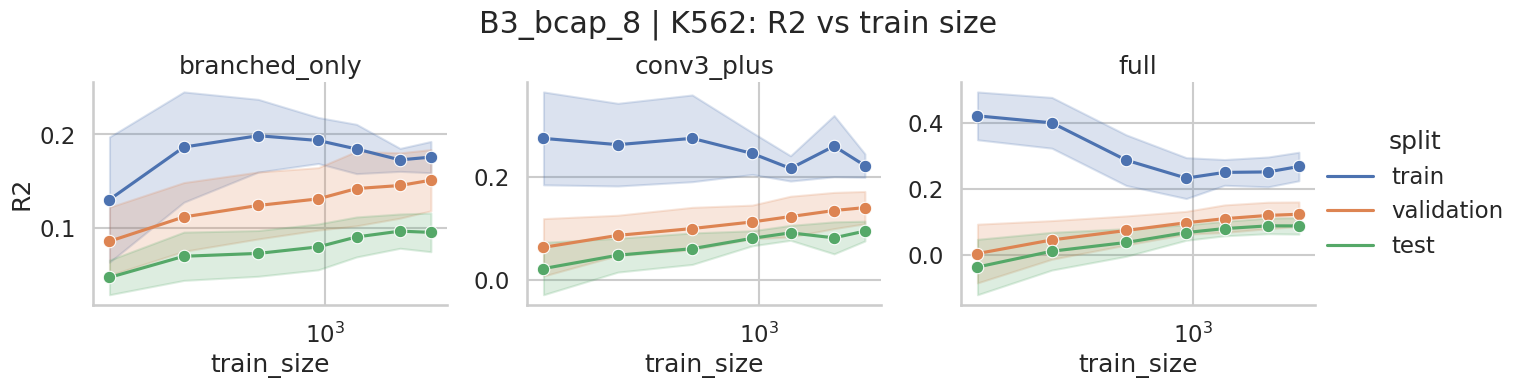

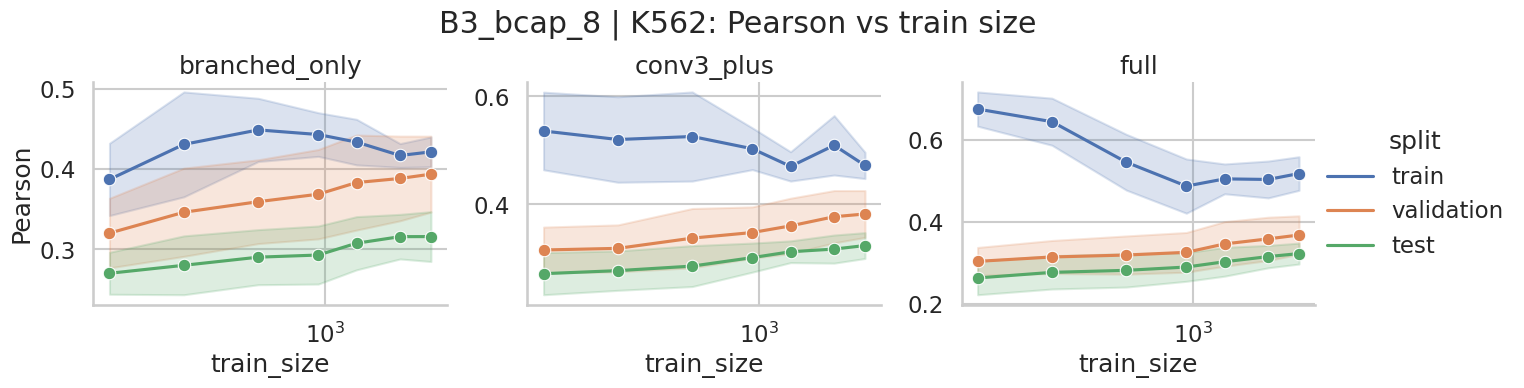

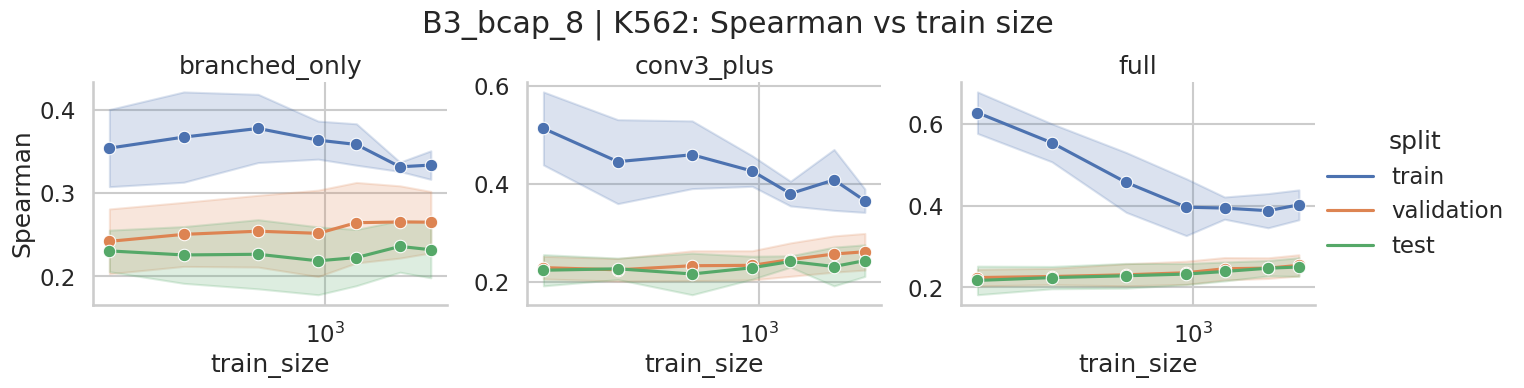

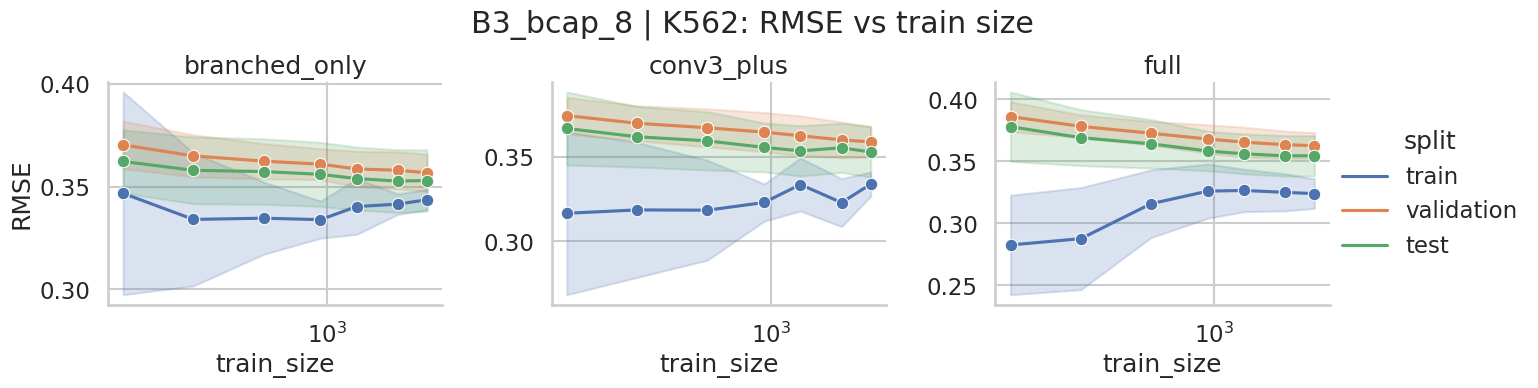

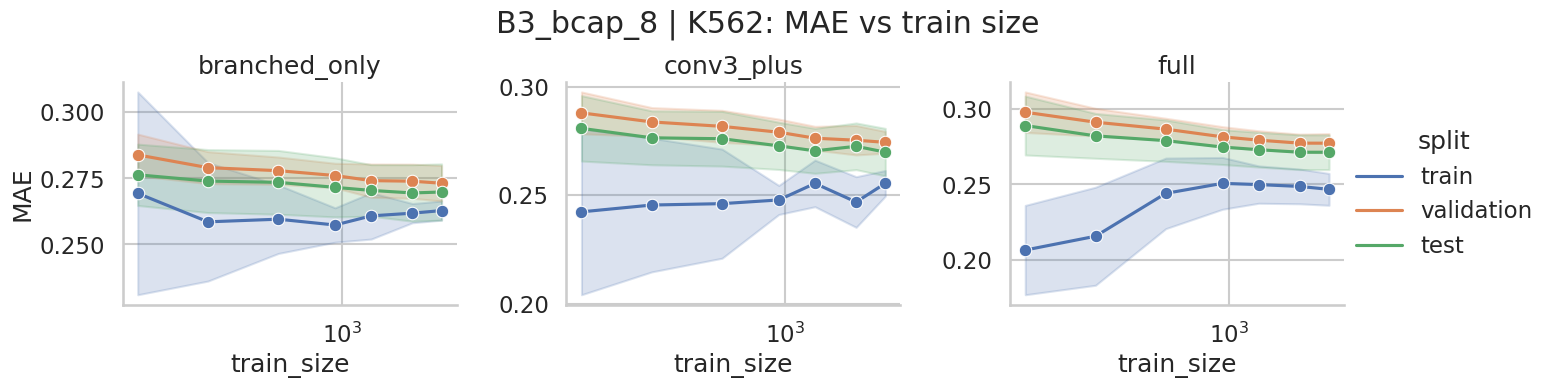

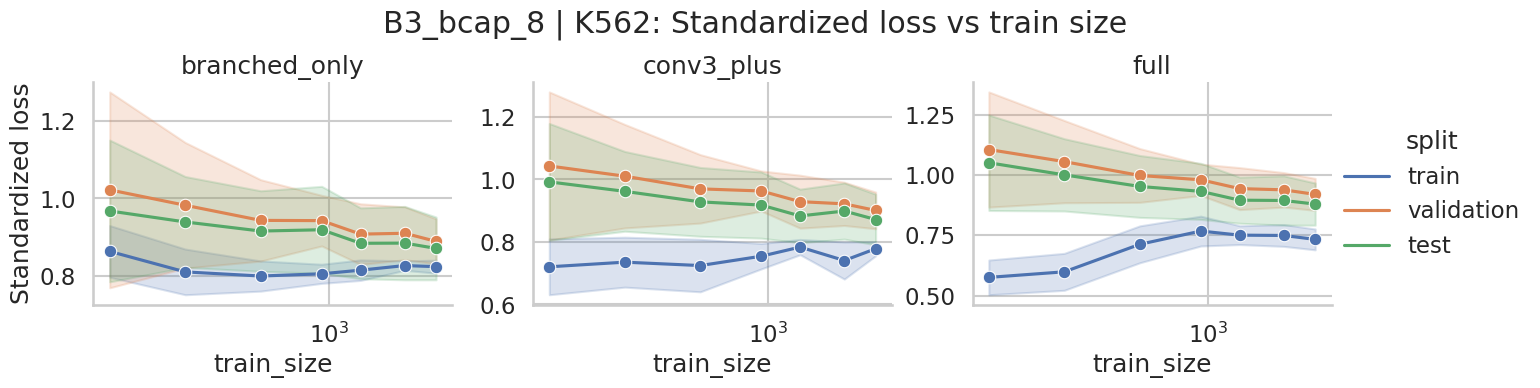

In [18]:
for metric_root, y_label in [
    ("r2", "R2"),
    ("pearson", "Pearson"),
    ("spearman", "Spearman"),
]:
    plot_final_metric_vs_train_size(runs_df, metric_root, y_label)
    plt.show()

for metric_root, y_label in [
    ("rmse", "RMSE"),
    ("mae", "MAE"),
    ("loss_standardized", "Standardized loss"),
]:
    plot_final_metric_vs_train_size(runs_df, metric_root, y_label)
    plt.show()

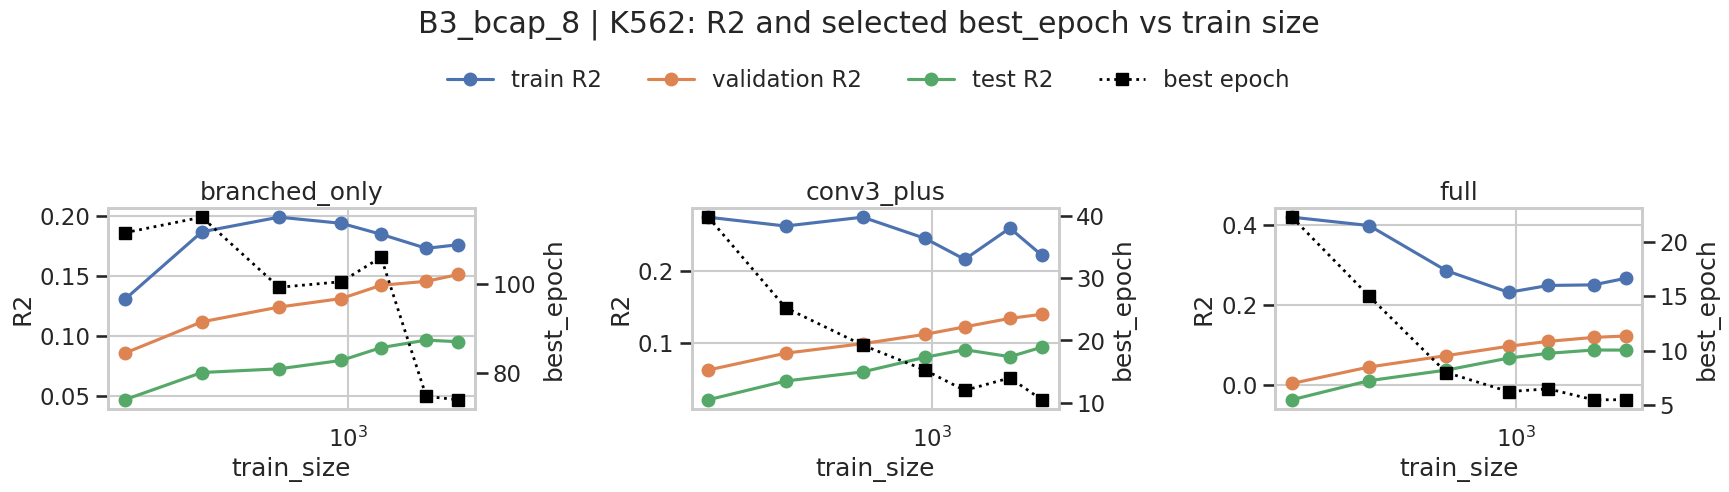

In [19]:
summary_plot_df = (
    runs_df.groupby(["unfreeze_scope", "train_size"], dropna=False)
    .agg(
        train_r2_mean=("train_r2", "mean"),
        val_r2_mean=("val_r2", "mean"),
        test_r2_mean=("test_r2", "mean"),
        best_epoch_mean=("best_epoch", "mean"),
        train_hq_fraction_mean=("train_hq_fraction", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
legend_handles = None
legend_labels = None

for ax, scope in zip(axes, scope_order):
    sub = summary_plot_df[summary_plot_df["unfreeze_scope"] == scope].sort_values("train_size")
    if sub.empty:
        ax.set_visible(False)
        continue

    ax.plot(sub["train_size"], sub["train_r2_mean"], marker="o", label="train R2", color="#4c72b0")
    ax.plot(sub["train_size"], sub["val_r2_mean"], marker="o", label="validation R2", color="#dd8452")
    ax.plot(sub["train_size"], sub["test_r2_mean"], marker="o", label="test R2", color="#55a868")
    ax.set_xscale("log")
    ax.set_xlabel("train_size")
    ax.set_ylabel("R2")
    ax.set_title(scope)

    ax2 = ax.twinx()
    ax2.plot(
        sub["train_size"],
        sub["best_epoch_mean"],
        marker="s",
        linestyle=":",
        linewidth=2,
        color="black",
        label="best epoch",
    )
    ax2.set_ylabel("best_epoch")
    ax2.grid(False)

    if legend_handles is None:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        legend_handles = lines1 + lines2
        legend_labels = labels1 + labels2

fig.suptitle(f"{setting_label} | {init_head}: R2 and selected best_epoch vs train size", y=1.06)
if legend_handles is not None:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=len(legend_labels),
        frameon=False,
    )
fig.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.show()

In [20]:
side_by_side_table = (
    runs_df.groupby(["unfreeze_scope", "train_size"], dropna=False)
    .agg(
        train_hq_fraction=("train_hq_fraction", "mean"),
        best_epoch=("best_epoch", "mean"),
        train_r2=("train_r2", "mean"),
        val_r2=("val_r2", "mean"),
        test_r2=("test_r2", "mean"),
        train_pearson=("train_pearson", "mean"),
        val_pearson=("val_pearson", "mean"),
        test_pearson=("test_pearson", "mean"),
    )
    .reset_index()
    .sort_values(["unfreeze_scope", "train_size"])
)

display(side_by_side_table)

,unfreeze_scope,train_size,train_hq_fraction,best_epoch,train_r2,val_r2,test_r2,train_pearson,val_pearson,test_pearson
0,branched_only,134,0.309701,111.50,0.130175,0.085495,0.046749,0.387323,0.320376,0.270252
1,branched_only,268,0.307836,115.00,0.186486,0.111585,0.069420,0.430996,0.346376,0.280209
2,branched_only,536,0.312034,99.25,0.198670,0.123885,0.072483,0.449051,0.359538,0.290355
3,branched_only,938,0.313966,100.50,0.193555,0.130954,0.079481,0.443292,0.368862,0.293023
4,branched_only,1340,0.314739,106.00,0.184439,0.142006,0.090120,0.433843,0.383399,0.307738
5,branched_only,2011,0.316012,74.75,0.172756,0.145294,0.096370,0.417148,0.388522,0.315945
6,branched_only,2681,0.318072,74.00,0.175734,0.150977,0.095021,0.421668,0.393871,0.316014
7,conv3_plus,134,0.309701,39.75,0.273986,0.062656,0.021467,0.535971,0.315450,0.271576
8,conv3_plus,268,0.307836,25.25,0.261805,0.085836,0.047387,0.520121,0.318487,0.277204
9,conv3_plus,536,0.312034,19.25,0.274074,0.099079,0.060007,0.525720,0.337423,0.285626


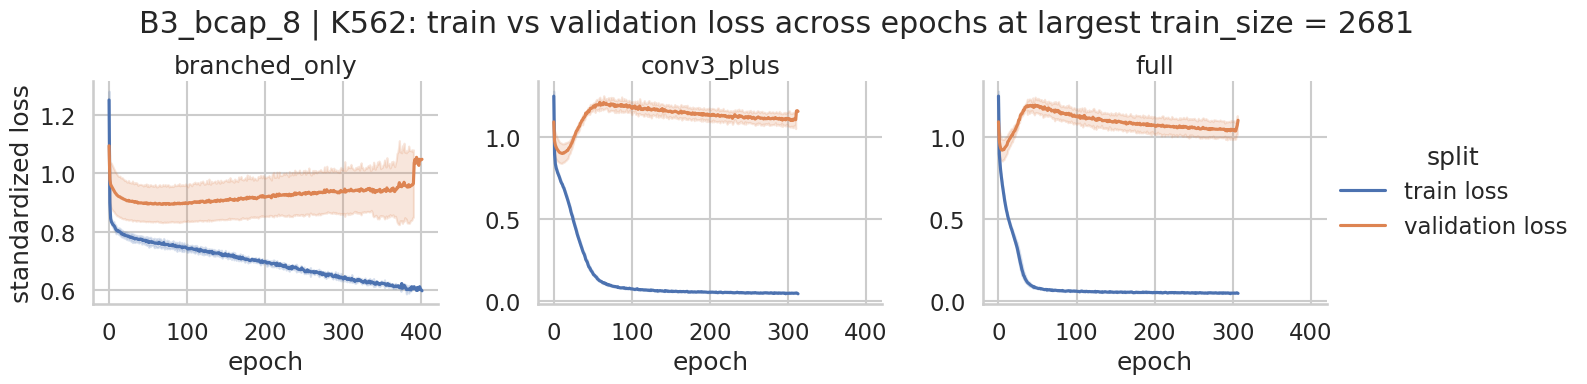

In [21]:
largest_train_size = max(train_size_order)
full_size_epoch_loss = hist_df.loc[hist_df["train_size"] == largest_train_size].copy()

loss_plot_df = full_size_epoch_loss.melt(
    id_vars=["unfreeze_scope", "epoch", "seed"],
    value_vars=["train_loss_standardized", "val_loss_standardized"],
    var_name="split",
    value_name="loss",
)
loss_plot_df["split"] = loss_plot_df["split"].map(
    {
        "train_loss_standardized": "train loss",
        "val_loss_standardized": "validation loss",
    }
)

g = sns.relplot(
    data=loss_plot_df,
    x="epoch",
    y="loss",
    hue="split",
    col="unfreeze_scope",
    col_order=scope_order,
    kind="line",
    estimator="mean",
    errorbar="sd",
    height=4,
    aspect=1.15,
    facet_kws={"sharex": True, "sharey": False},
)
g.set_axis_labels("epoch", "standardized loss")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.80)
g.fig.suptitle(
    f"{setting_label} | {init_head}: train vs validation loss across epochs at largest train_size = {largest_train_size}",
    y=0.98,
)
plt.show()

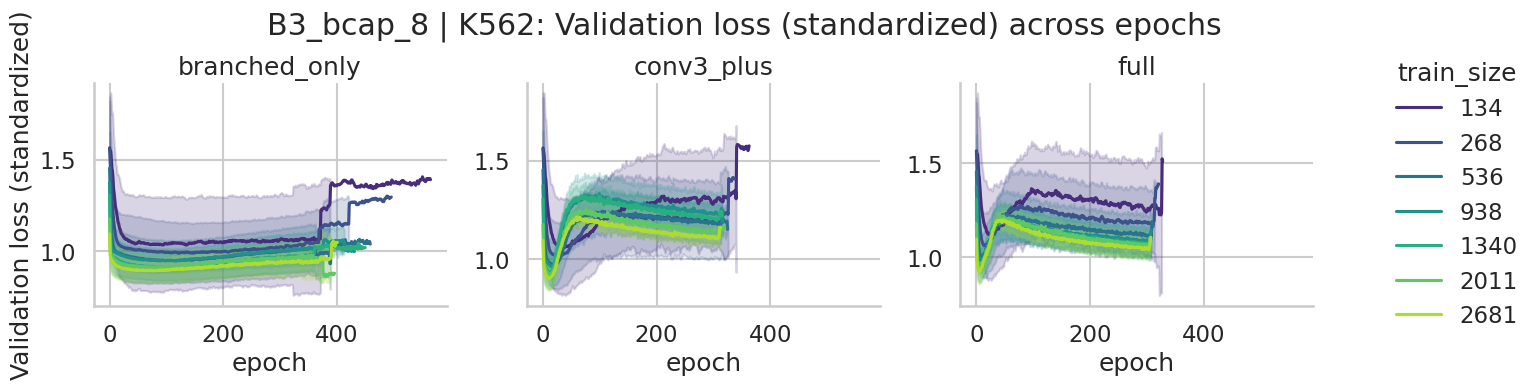

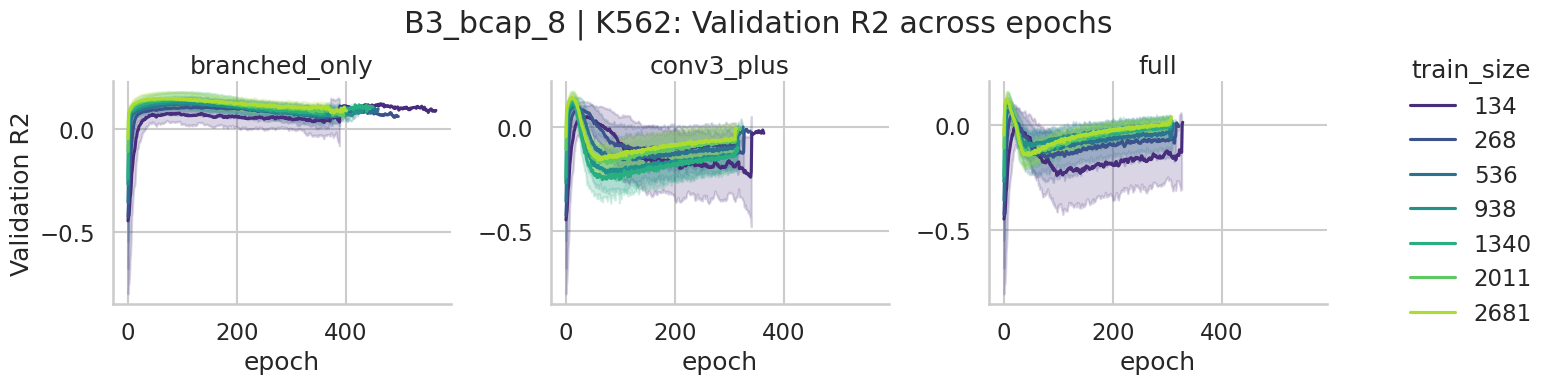

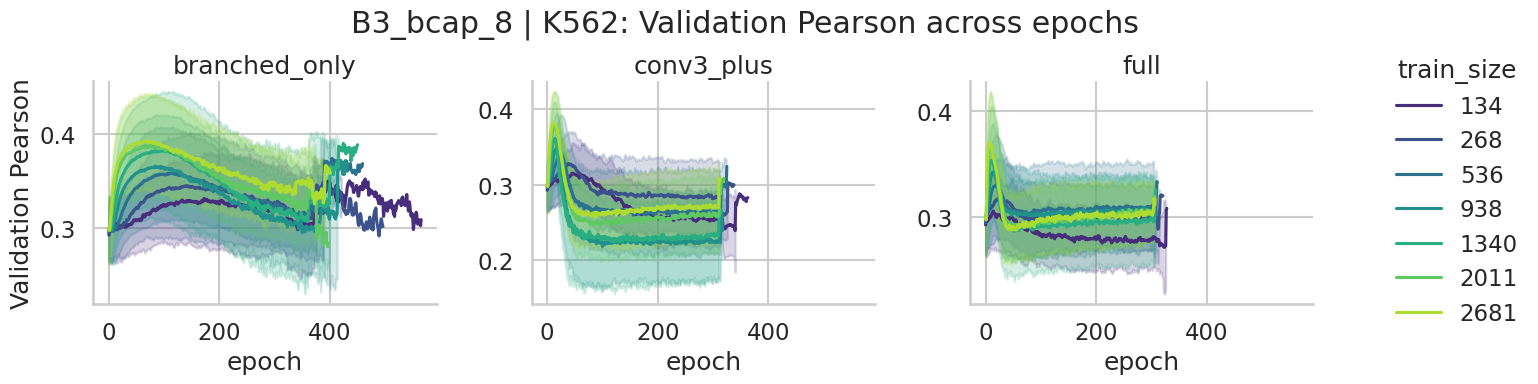

In [22]:
for metric_col, y_label in [
    ("val_loss_standardized", "Validation loss (standardized)"),
    ("val_r2", "Validation R2"),
    ("val_pearson", "Validation Pearson"),
]:
    plot_epoch_metric(hist_df, metric_col, y_label)
    plt.show()

### Test R2 across epochs for all train sizes

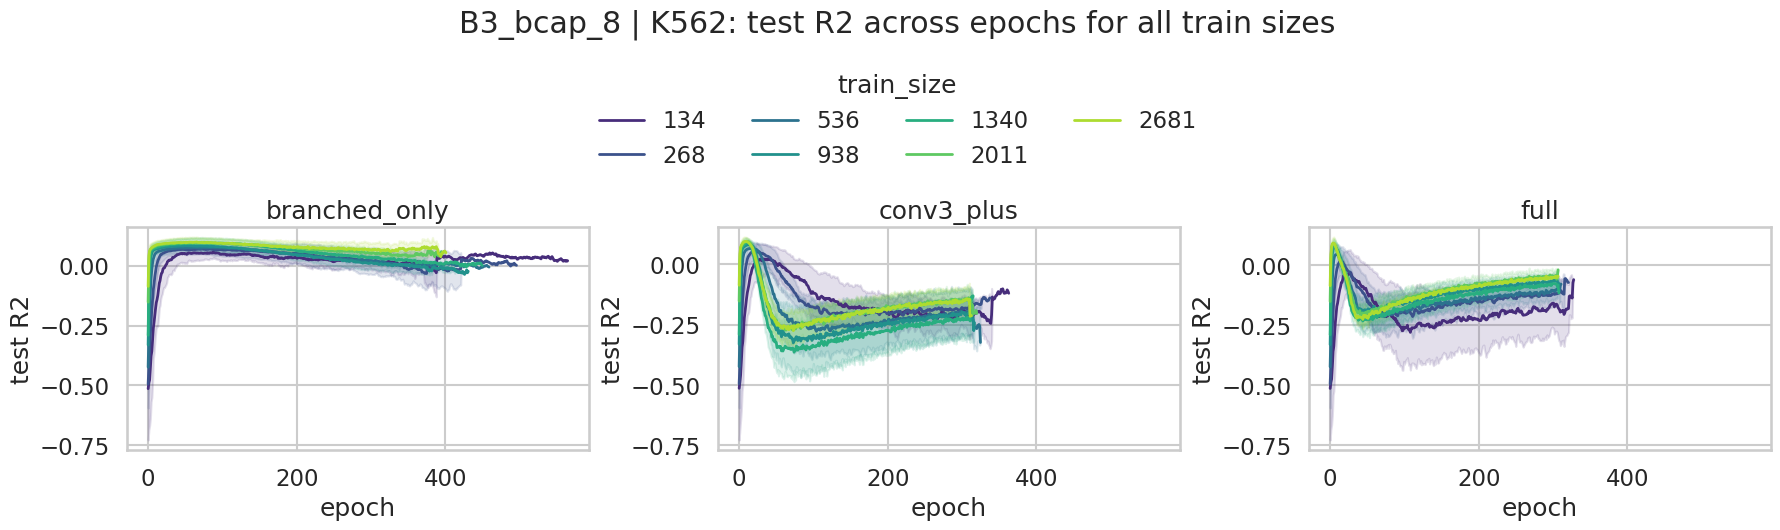

In [23]:
from matplotlib.lines import Line2D

train_size_order_int = [int(x) for x in train_size_order]
train_size_palette = dict(zip(train_size_order_int, sns.color_palette("viridis", n_colors=len(train_size_order_int))))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=False)

for ax, scope in zip(axes, scope_order):
    scope_df = hist_df[hist_df["unfreeze_scope"] == scope].copy()
    if scope_df.empty:
        ax.set_visible(False)
        continue

    for train_size in train_size_order_int:
        size_df = scope_df[scope_df["train_size"] == train_size].copy()
        if size_df.empty:
            continue

        epoch_summary = (
            size_df.groupby("epoch", dropna=False)["test_r2"]
            .agg(["mean", "std"])
            .reset_index()
            .rename(columns={"mean": "test_r2_mean", "std": "test_r2_sd"})
        )
        y = epoch_summary["test_r2_mean"].to_numpy()
        err = epoch_summary["test_r2_sd"].fillna(0).to_numpy()
        color = train_size_palette[train_size]

        ax.plot(epoch_summary["epoch"], y, color=color, linewidth=2)
        ax.fill_between(epoch_summary["epoch"], y - err, y + err, color=color, alpha=0.15)

    ax.set_title(scope)
    ax.set_xlabel("epoch")
    ax.set_ylabel("test R2")

legend_handles = [
    Line2D([0], [0], color=train_size_palette[train_size], linewidth=2, label=str(train_size))
    for train_size in train_size_order_int
]
fig.legend(
    legend_handles,
    [str(train_size) for train_size in train_size_order_int],
    title="train_size",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    frameon=False,
)
fig.suptitle(f"{setting_label} | {init_head}: test R2 across epochs for all train sizes", y=1.12)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

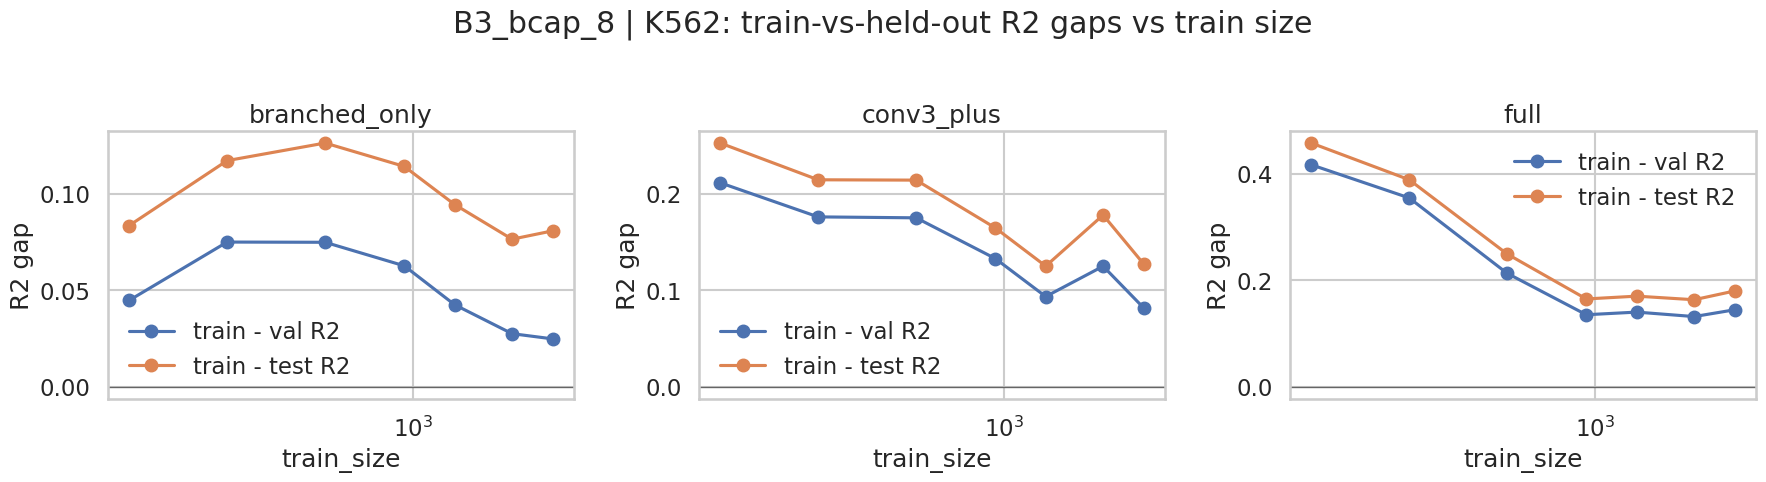

In [10]:
gap_df = (
    runs_df.groupby(["unfreeze_scope", "train_size"], dropna=False)
    .agg(
        train_r2_mean=("train_r2", "mean"),
        val_r2_mean=("val_r2", "mean"),
        test_r2_mean=("test_r2", "mean"),
        best_epoch_mean=("best_epoch", "mean"),
    )
    .reset_index()
)
gap_df["train_val_r2_gap"] = gap_df["train_r2_mean"] - gap_df["val_r2_mean"]
gap_df["train_test_r2_gap"] = gap_df["train_r2_mean"] - gap_df["test_r2_mean"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
for ax, scope in zip(axes, scope_order):
    sub = gap_df[gap_df["unfreeze_scope"] == scope].sort_values("train_size")
    ax.plot(sub["train_size"], sub["train_val_r2_gap"], marker="o", label="train - val R2")
    ax.plot(sub["train_size"], sub["train_test_r2_gap"], marker="o", label="train - test R2")
    ax.set_xscale("log")
    ax.set_xlabel("train_size")
    ax.set_ylabel("R2 gap")
    ax.set_title(scope)
    ax.axhline(0.0, color="black", linewidth=1, alpha=0.5)
    ax.legend(frameon=False)
fig.suptitle(f"{setting_label} | {init_head}: train-vs-held-out R2 gaps vs train size", y=1.02)
fig.tight_layout()
plt.show()

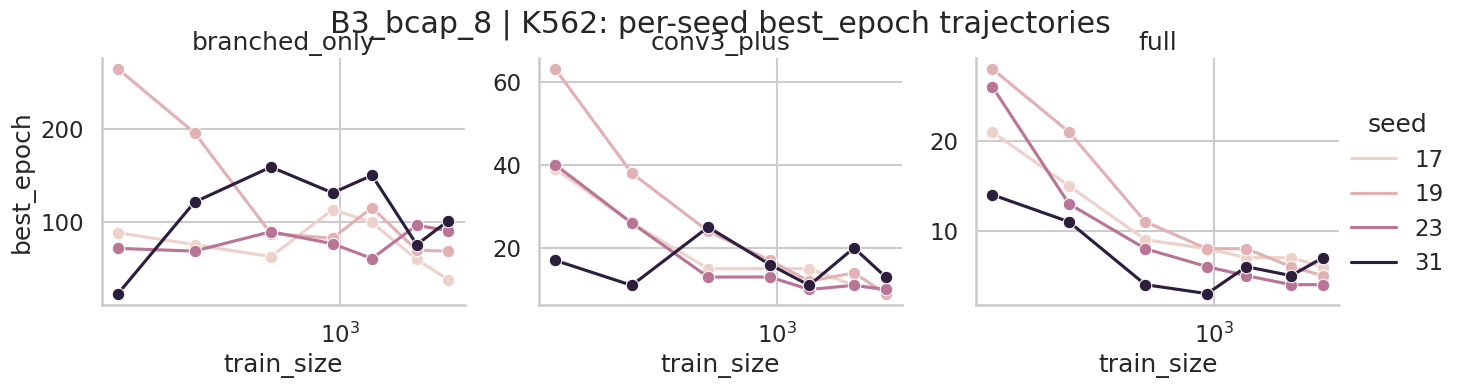

In [24]:
g = sns.relplot(
    data=runs_df,
    x="train_size",
    y="best_epoch",
    hue="seed",
    col="unfreeze_scope",
    col_order=scope_order,
    kind="line",
    marker="o",
    height=4,
    aspect=1.15,
    facet_kws={"sharex": True, "sharey": False},
)
g.set(xscale="log")
g.set_axis_labels("train_size", "best_epoch")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.86)
g.fig.suptitle(f"{setting_label} | {init_head}: per-seed best_epoch trajectories")
plt.show()

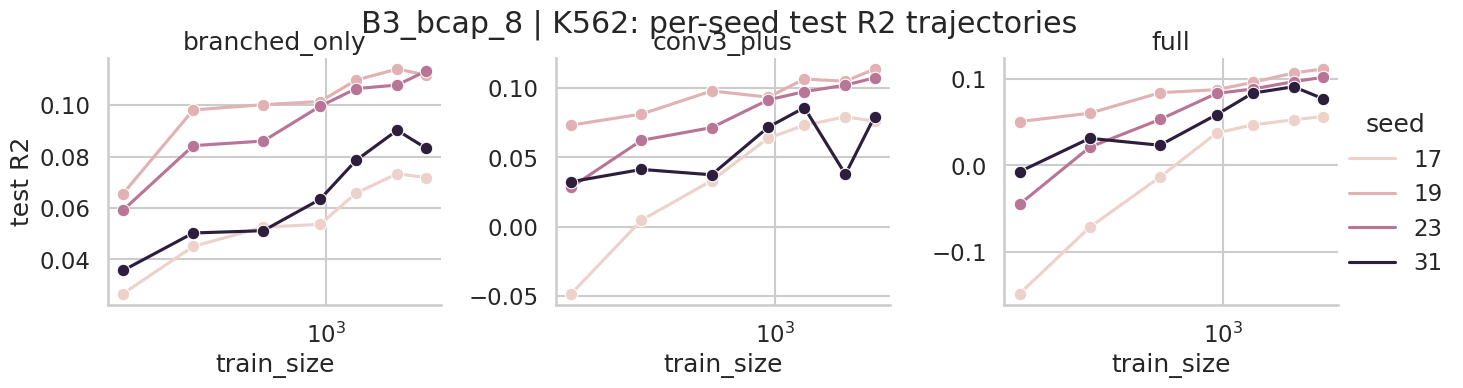

In [25]:
g = sns.relplot(
    data=runs_df,
    x="train_size",
    y="test_r2",
    hue="seed",
    col="unfreeze_scope",
    col_order=scope_order,
    kind="line",
    marker="o",
    height=4,
    aspect=1.15,
    facet_kws={"sharex": True, "sharey": False},
)
g.set(xscale="log")
g.set_axis_labels("train_size", "test R2")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.86)
g.fig.suptitle(f"{setting_label} | {init_head}: per-seed test R2 trajectories")
plt.show()

In [26]:
marginal_gain_df = (
    runs_df.groupby(["unfreeze_scope", "train_size"], dropna=False)
    .agg(test_r2_mean=("test_r2", "mean"), val_r2_mean=("val_r2", "mean"))
    .reset_index()
)

marginal_gain_df = add_marginal_gain_columns(marginal_gain_df, "test_r2_mean")
display(marginal_gain_df)

,unfreeze_scope,train_size,test_r2_mean,val_r2_mean,delta_size,delta_metric,gain_per_sample,gain_per_1000_samples
0,branched_only,134,0.046749,0.085495,NaN,NaN,NaN,NaN
1,branched_only,268,0.069420,0.111585,134.0,0.022671,1.691883e-04,0.169188
2,branched_only,536,0.072483,0.123885,268.0,0.003063,1.142751e-05,0.011428
3,branched_only,938,0.079481,0.130954,402.0,0.006998,1.740857e-05,0.017409
4,branched_only,1340,0.090120,0.142006,402.0,0.010639,2.646462e-05,0.026465
5,branched_only,2011,0.096370,0.145294,671.0,0.006250,9.314440e-06,0.009314
6,branched_only,2681,0.095021,0.150977,670.0,-0.001349,-2.013195e-06,-0.002013
7,conv3_plus,134,0.021467,0.062656,NaN,NaN,NaN,NaN
8,conv3_plus,268,0.047387,0.085836,134.0,0.025919,1.934275e-04,0.193427
9,conv3_plus,536,0.060007,0.099079,268.0,0.012621,4.709296e-05,0.047093


## Notes

- This long-epoch rerun is much simpler than the earlier targeted notebook: one setting, one `init_head`, one LR pair, and random per-seed splits.
- The double-y plot is the most direct view of the concern we discussed: whether the selected checkpoint that generalizes best is also one that fits the training data strongly.
- The epoch plots can only show `train_loss_standardized` and validation metrics because per-epoch train/test evaluation metrics were not cached.
- If we want true per-epoch `test R2` in a future rerun, the training script would need to evaluate the test split every epoch and append those metrics to the history file.